![](twisting.png)

## Environment Setup

### Directories

In [1]:
import sys
from pathlib import Path
import importlib

nb_folder = Path().resolve()
PROBLEM_NAME = nb_folder.name
parent_folder = nb_folder.parent
if str(parent_folder) not in sys.path:
    sys.path.insert(0, str(parent_folder))

### Standard Imports

In [2]:
#Standard Imports and class import
#Standard Imports and class import
from skrom.utils.imports import *
from skrom.rom.rom_utils import *
from skrom.utils.reduced_basis.svd import svd_mode_selector
from skrom.rom.rom_error_est import *
from skrom.fom.fem_utils import load_domain
from skrom.utils.visualization.plot_utils import *
import skrom.problem_classes.static.master_class as master
problem_mod = importlib.import_module(f"{PROBLEM_NAME}.problem_def") #- this runs @register_problem

# SKROM ROM (Reduced Order Modeling) core classes
from skrom.rom.linear_form_rom import LinearFormROM
from skrom.rom.ecsw.hyperreduce import hyperreduce
from problem_def import ProblemNonLinear
# Problem-specific linear forms
from linear_forms import R

### Plot Properties


## Full Order Simulation


In [3]:
# Control flag for expensive simulation generation

generate = True

# Conditional execution block for simulation data generation
if generate:
    # Create an instance of the non-linear heat conduction simulation
    sim = master.fom_simulation(num_snapshots = 32)
    sim.run_simulation()


Snap 1/64 params=[0.94023875 1.76986685]
1 9.792750038477196
2 0.989837021006074
3 1.7261455469117737
4 0.4574897002573785
5 1.2744349304718634
6 0.09760823049156174
7 0.17965242007375282
8 0.0010089405509650644
9 2.6625099328946107e-06
Snap 2/64 params=[0.54927994 1.0191219 ]
1 0.0002584000146732142
Snap 3/64 params=[0.70073854 1.68086155]
1 0.004742213109563519
2 9.403428304097568e-06
Snap 4/64 params=[0.8097759  1.43646449]
1 0.005523618095848342
2 1.0166580215035633e-05
Snap 5/64 params=[0.81801016 1.56402212]
1 0.0013372587348838797
2 6.976555495543311e-07
Snap 6/64 params=[0.67687975 1.31865044]
1 0.00033798223452058553
Snap 7/64 params=[0.57315018 1.98136605]
1 0.011140296152748698
2 5.9155721918272204e-05
Snap 8/64 params=[0.93199305 1.22964647]
1 0.01765225772006045
2 7.981776308891919e-05
Snap 9/64 params=[0.8979087  1.70816293]
1 0.006284996251098783
2 1.733931193012145e-05
Snap 10/64 params=[0.60137516 1.45597793]
1 0.004470231056472218
2 8.296264393704956e-06
Snap 11/64 pa

### Load Simulation Data

In [4]:
#Load the ROM_data
current_dir = Path().resolve()
rom_dir = current_dir / "ROM_data"
fos_solutions, sim_data = load_rom_data(self=None, rom_data_dir=rom_dir)

[load_rom_data] loaded from D:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


## Data Generation

### Generate Training Solution Dataset



In [5]:
# Convert parameter list to a NumPy array (representing system parameters)
# This contains the parameter values for each simulation run (e.g., thermal conductivity, 
# boundary conditions, material properties, etc.)
param_list = np.asarray(sim_data['param_list'])

# Load non-linear solutions from the full-order system
# NLS contains the high-fidelity finite element solutions for each parameter set
# Each row represents a complete solution snapshot (discretized spatial field)
NLS = np.asarray(fos_solutions)

# Split data into training and testing using predefined masks
# These boolean masks determine which snapshots are used for ROM training vs validation
train_mask, test_mask = sim_data['train_mask'], sim_data['test_mask']

# Apply masks to filter non-linear solutions for training and testing
# Training set: Used to construct the ROM basis functions and train the model
NLS_train = NLS[train_mask]  # Training snapshots with Dirichlet boundary conditions applied

# Testing set: Used to evaluate ROM accuracy and performance on unseen data
NLS_test = NLS[test_mask]    # Testing snapshots with Dirichlet boundary conditions applied

# Get the number of snapshots (parameter samples or time instances)
# N_snap: Total number of simulation snapshots available
# Second dimension: Number of degrees of freedom (DOFs) in the spatial discretization
N_snap, _ = np.shape(NLS)

# Display the total number of snapshots for verification
print(N_snap)  # Print the number of snapshots available

64


### Mean Subtraction

In [6]:
# Compute the mean temperature field across all training snapshots
# This represents the "average" or "reference" temperature distribution
# Shape: [N_dof] - one mean value for each spatial degree of freedom
NLS_train_mean = np.mean(NLS_train, axis=0)

# Mean-center the training data by subtracting the mean field
# This creates fluctuations/deviations from the mean temperature distribution
# Shape: [N_train_snapshots, N_dof] - same as original but now mean-centered
# Each row now represents how much each snapshot deviates from the average
NLS_train_ms = NLS_train - NLS_train_mean

#We will use SVD on the mean subtracted matrix data

### Distribution of the training parameters

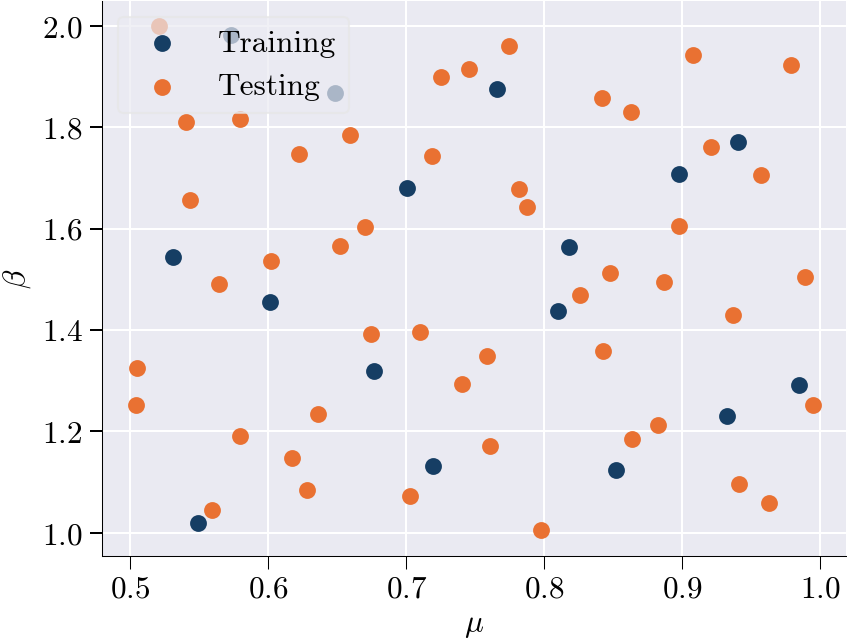

In [7]:
# Visualize the parameter space distribution for training and testing data
# Plot training parameter combinations (first 16 samples)
# Extract first and second parameter columns for 2D visualization
plt.scatter(param_list[:16][:, 0],    # First parameter (μ) for training samples which are the k_params 
           param_list[:16][:, 1],     # Second parameter (β) for training samples which are the q_params
           s=50,                      # Marker size
           c='#163e64',              # Dark blue color for training points
           label="Training")         # Legend label

# Plot testing parameter combinations (samples 17 and beyond)
plt.scatter(param_list[16:][:, 0],    # First parameter (μ) for testing samples
           param_list[16:][:, 1],     # Second parameter (β) for testing samples
           s=50,                      # Marker size (same as training)
           c='#e97132',              # Orange color for testing points
           label="Testing")          # Legend label

# Set axis labels using LaTeX formatting for mathematical notation
plt.xlabel("$\\mu$")        # First parameter (often material property, conductivity, etc.) this is the k_params
plt.ylabel("$\\beta$")     # Second parameter (often boundary condition, heat source, etc.) this is the q_params

# Add legend to distinguish between training and testing sets
plt.legend()

#See params and properties to see how these are used

### Performing SVD on training snapshots

Number of modes selected: 8


Text(0.5, 0, 'POD modes ($k$)')

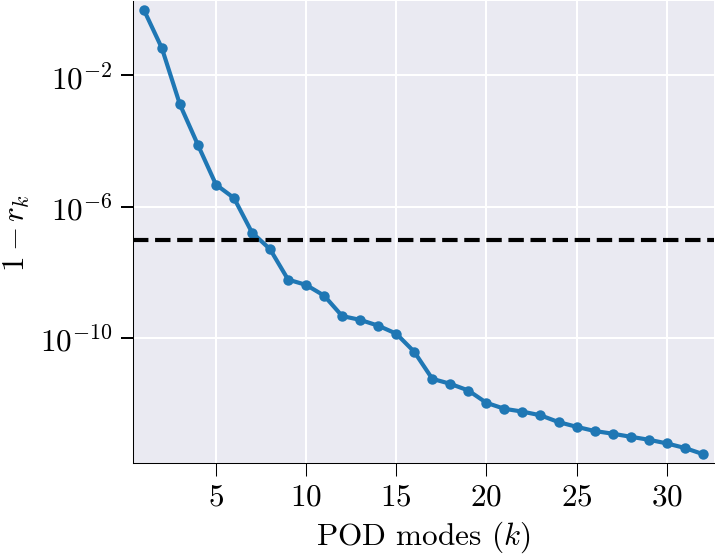

In [8]:
# Configure plot styling for POD analysis visualization
plt.rcParams['lines.markersize'] = 6      # Set marker size for data points
plt.rcParams['lines.linewidth'] = 2.0     # Set line thickness for better visibility

# Perform Singular Value Decomposition (SVD) for POD mode selection
# SVD decomposes the mean-centered training data to find optimal basis functions
n_sel, U = svd_mode_selector(NLS_train_ms,    # Input: mean-centered training snapshots
                            tolerance=1e-7,    # Convergence criterion for mode selection
                            modes=True)        # Return both number of modes and basis vectors

n_sel = 6

# Extract the selected POD basis vectors (spatial modes)
# V_sel contains the first n_sel most energetic POD modes
# Shape: [N_dof, n_sel] - each column is a spatial basis function
V_sel = U[:, :n_sel]  # This will be passed to the ROM simulation function

# Set axis labels for the POD energy plot (generated by svd_mode_selector)
plt.ylabel('$1-r_{k}$')           # Energy not captured by first k modes
plt.xlabel('POD modes ($k$)')     # Number of POD modes retained

## ROM Simulation


In [9]:
# Initialize the reduced-order model (ROM) simulation
#   V_sel : precomputed basis matrix (e.g., selected POD modes)
#   n_sel : number of basis vectors (modes) to retain in the ROM
rom = master.rom_simulation(V_sel=V_sel, n_sel = n_sel)

[load_rom_data] loaded from d:\OneDrive - Texas A&M University\SKROM\scikit-rom\examples\computational_mechanics\static\non_linear\problem_1_h\ROM_data


In [10]:
# Run the reduced-order model (ROM) simulation.
# rom object will contain the NLS rom simulation solutions and other simulation aspects required by ROM such as the param_list etc.
generate = True
if generate:
    rom.run_rom_simulation();
#Returns the Newton iteration errors just like full order simulation

Snap 1/64 params=[0.89781157 1.6046292 ]
1 0.0022031560526087623
2 1.4343792095370062e-06
Snap 2/64 params=[0.63622413 1.23471286]
1 0.0014734292248067327
2 8.560647161171499e-07
Snap 3/64 params=[0.52065523 1.99901204]
1 0.013405970095652692
2 7.557299744510392e-05
Snap 4/64 params=[0.75880087 1.34914577]
1 0.014848825700682938
2 6.479611896360975e-05
Snap 5/64 params=[0.84142984 1.85704593]
1 0.003929152461353576
2 6.248372546389618e-06
Snap 6/64 params=[0.56418783 1.4911119 ]
1 0.0034369397372068272
2 4.552574825934313e-06
Snap 7/64 params=[0.71863756 1.74244539]
1 0.0016597406015274653
2 9.793342562710061e-07
Snap 8/64 params=[0.94118969 1.09689665]
1 0.012669945141206342
2 5.1648636911255416e-05
Snap 9/64 params=[0.97892711 1.922586  ]
1 0.008854062590340573
2 3.493596501508437e-05
Snap 10/64 params=[0.74053339 1.2927288 ]
1 0.0021026536294902927
2 1.656307083193089e-06
Snap 11/64 params=[0.60164858 1.53651637]
1 0.0070279411089936615
2 2.061610989639519e-05
Snap 12/64 params=[0.8

In [11]:
#Assign values for the statistics
NLS_rom = np.asarray(rom.rom_solutions)
ROM_speed_up = rom.speed_up
ROM_speed_up=ROM_speed_up
ROM_relative_error = rom.rom_error

### ROM solution vs. Full order solution performance statistics 

ROM Accuracy Report

Global Errors:
L2 Error:                 3.9316e-09
Relative L2 Error:        2.2560e-09
L∞ Error:                 4.0051e-09
Relative L∞ Error:        7.5155e-09
RMSE:                     2.9967e-10
MAE:                      7.2373e-11

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0000

Error Distribution:
Median Error:             0.0000e+00
95th Percentile Error:    2.3398e-10

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 2.3940e-11
Max Rel L2 Error over time/parameter: 3.8671e-10
Min Rel L2 Error over time/parameter: 8.1940e-13
――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

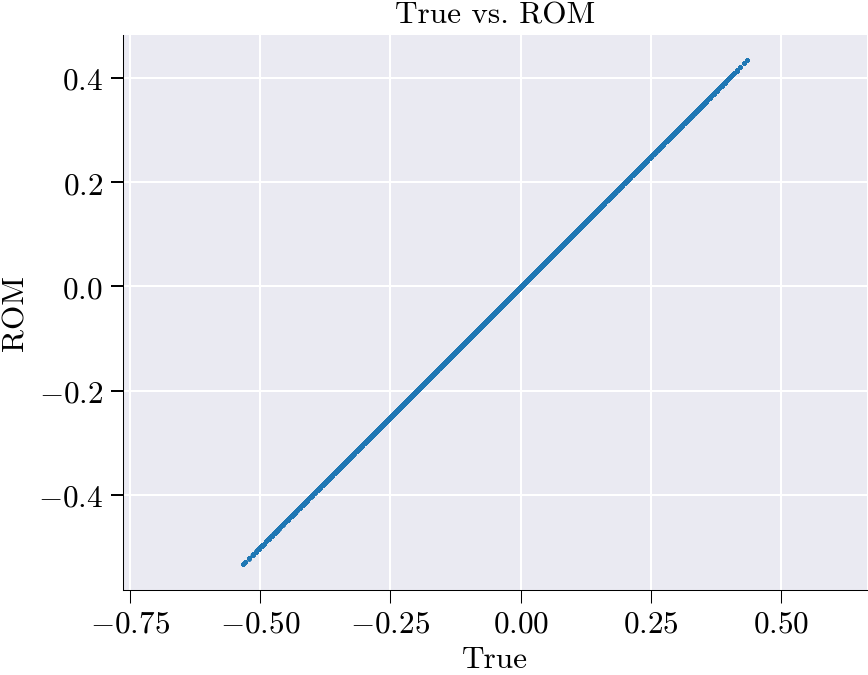

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


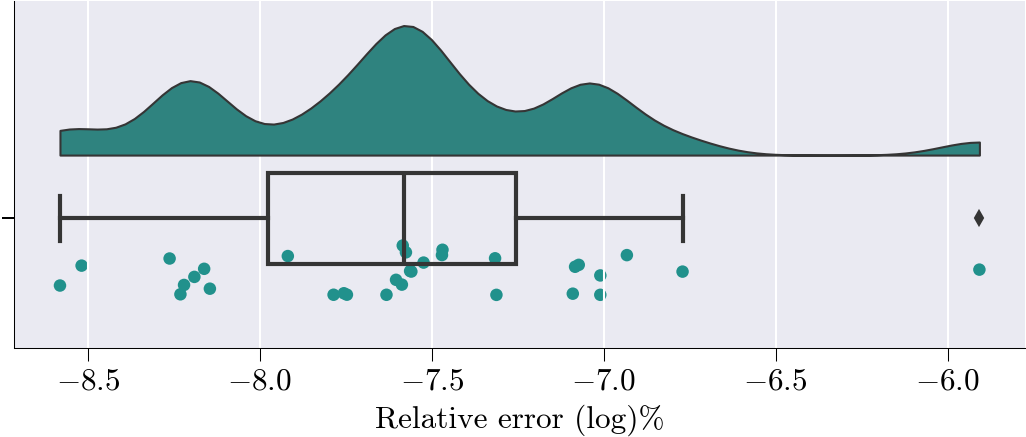

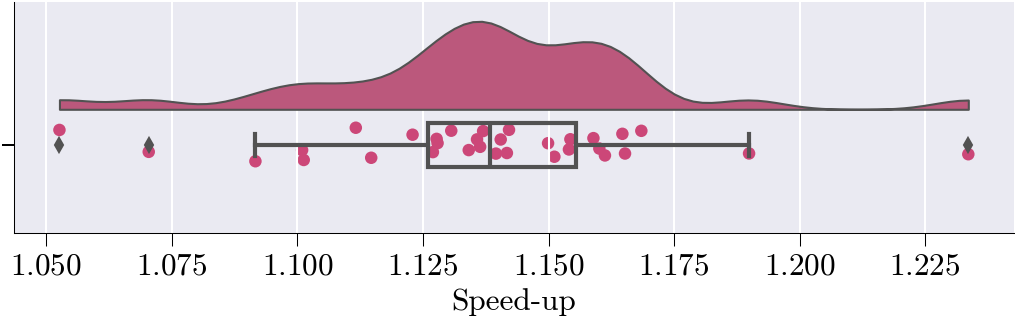

In [12]:
# --- Standard ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_rom)

# Produce a text-based report summarizing these error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the standard ROM
plot_rom_error_diagnostics_flat(
    NLS_test,               # full-order (true) solution snapshots
    NLS_rom,                # ROM-generated solution snapshots
    ROM_relative_error,     # precomputed relative error of the ROM
    ROM_speed_up,           # precomputed speed-up factor of the ROM
    sim_axis=['True', 'ROM'], 
    metrics=matrix          # the matrix of error metrics just computed
)


## Hyper ROM Simulation


### Mesh Sampling


In [13]:
prob = ProblemNonLinear()
sim_data['dirichlet_dofs'] = prob.domain()['dirichlet_dofs']
free_dofs = sim_data['basis'].item().complement_dofs(sim_data['dirichlet_dofs'])
prob.mesh = sim_data['mesh'].item()  
# Get the finite element basis object for ROM construction
# This contains the spatial discretization information and basis functions
basis = sim_data['basis'].item()


In [14]:
# Create the ROM residual linear form object
# This represents the linear form R(u,v) in the weak formulation of the PDE
Residual = LinearFormROM(R,                    # Linear form function from problem definition
                         basis,                 # Finite element basis functions
                         V_sel,                 # Selected POD modes (reduced basis)
                         free_dofs=free_dofs)   # Free DOFs (excluding Dirichlet boundaries)

# Extract parameter values corresponding to training snapshots
# Uses the boolean mask to get only the parameter combinations used for training
training_params = param_list[train_mask]

In [15]:
# Collect residual evaluations for all training snapshots
# This creates the dataset needed for hyperreduction of nonlinear ROM terms
q_mus = collect_residuals(
    NLS_train_ms,         # Mean-centered training snapshots
    NLS_train_mean,       # Mean temperature field
    V_sel,                # Selected POD basis modes
    reconstruct_solution, # Solution reconstruction function
    Residual,             # ROM residual operator
    training_params,
    prob.assemble_kwargs,
)

# Display the shape of collected residuals for verification
# Shape should be: (n_training_snapshots * SVD components, n_residual_evaluation_points)
print(q_mus.shape)

#Output should be 16(for training snapshots) * 5(SVD components selected) = 80

(192, 1250)


#### Performing the SVD on snapshots

Performing SVD...
magnitude of d_q: 31.91784596883413


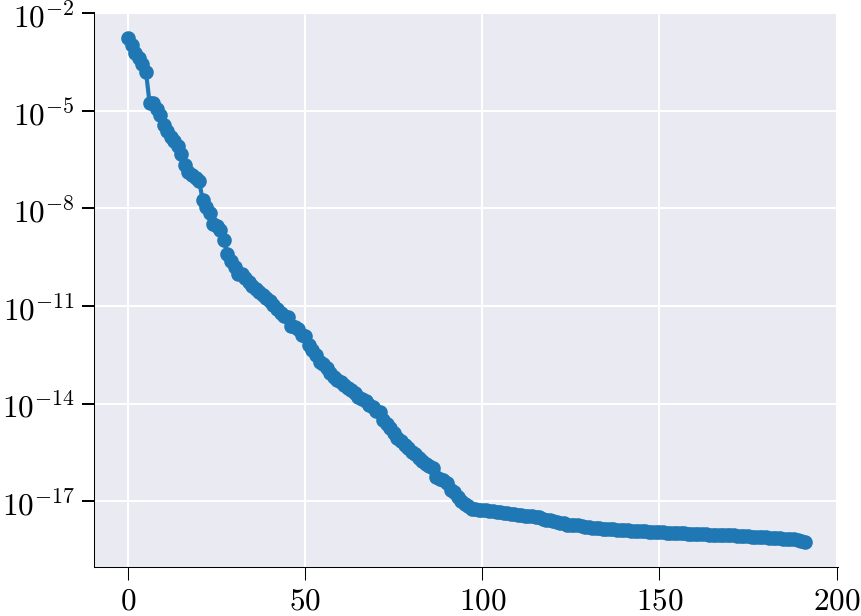

In [16]:
print("Performing SVD...")
# Performs Singular Value Decomposition on q_mus matrix
# Returns U (left singular vectors), s (singular values), Vh (right singular vectors transposed)
Uh, s, Vh = np.linalg.svd(q_mus, full_matrices=False)

# Plots singular values on a logarithmic y-scale to visualize their decay
# This helps identify the effective rank/dimensionality of the matrix
plt.semilogy(s, 'o-')

# Takes the first 20 right singular vectors (rows of Vh)
# This creates a reduced basis capturing the most significant modes
V_q_eff = Vh[:100]

# Computes a weighted combination of the basis vectors
# Each basis vector is weighted equally (multiplied by 1)
# This essentially sums all 20 basis vectors
d_q = V_q_eff @ np.ones(V_q_eff.shape[1])

# Outputs the L2 norm of the resulting vector
# This gives a sense of the magnitude of the combined basis representation
print("magnitude of d_q:", np.linalg.norm(d_q))

#### NNLS matrix

In [17]:
# Solve the non-negative least squares (NNLS) problem using hyperreduce
#   V_q_eff   : effective basis matrix
#   verbosity : level of log output (2 = detailed)
#   const_tol : tolerance for column selection
#   zero_tol  : tolerance to treat values as zero
#   plot      : disable plotting
x_nnls_m, err = hyperreduce(
    V_q_eff,
    verbosity=2,
    const_tol=1e-8,
    zero_tol=1e-8,
    plot=False
)

# Compute and print the relative NNLS reconstruction error:
#   ‖q_mus·(x_nnls_m – 1)‖ / ‖q_mus·1‖
rel_error = np.linalg.norm(q_mus @ (x_nnls_m - np.ones_like(x_nnls_m)))
rel_error /= np.linalg.norm(q_mus @ np.ones_like(x_nnls_m))
print("NNLS error:", rel_error)

NNLSSolver init (Sequential Version)

Starting NNLS solve...
0 0 100 1250 0 9.245908031108188e+00 3.191784596883413e+01
1 1 100 1250 1 8.534050501811825e+00 3.179314374915965e+01
2 2 100 1250 2 8.237259784340710e+00 3.155649384319375e+01
3 3 100 1250 3 8.063777213368704e+00 3.131754738718986e+01
4 4 100 1250 4 7.873926820494628e+00 3.113208407198712e+01
5 5 100 1250 5 8.030770594521627e+00 3.098604689108800e+01
6 6 100 1250 6 8.008528369889985e+00 3.082226021867662e+01
7 7 100 1250 7 7.718187891880494e+00 3.036010271770133e+01
8 8 100 1250 8 8.273994653856779e+00 3.013054086826266e+01
9 9 100 1250 9 8.422095956339982e+00 2.982565950013170e+01
10 10 100 1250 10 8.549047411081446e+00 2.969776811450312e+01
11 11 100 1250 11 7.907620380169135e+00 2.959138953709004e+01
12 12 100 1250 12 7.884061251422736e+00 2.950301004298018e+01
13 13 100 1250 13 7.661092859759842e+00 2.930446176697986e+01
14 14 100 1250 14 7.895832887073018e+00 2.913018849904291e+01
15 15 100 1250 15 8.098299234265092e+00

#### Plot Reduced Meshes with weights

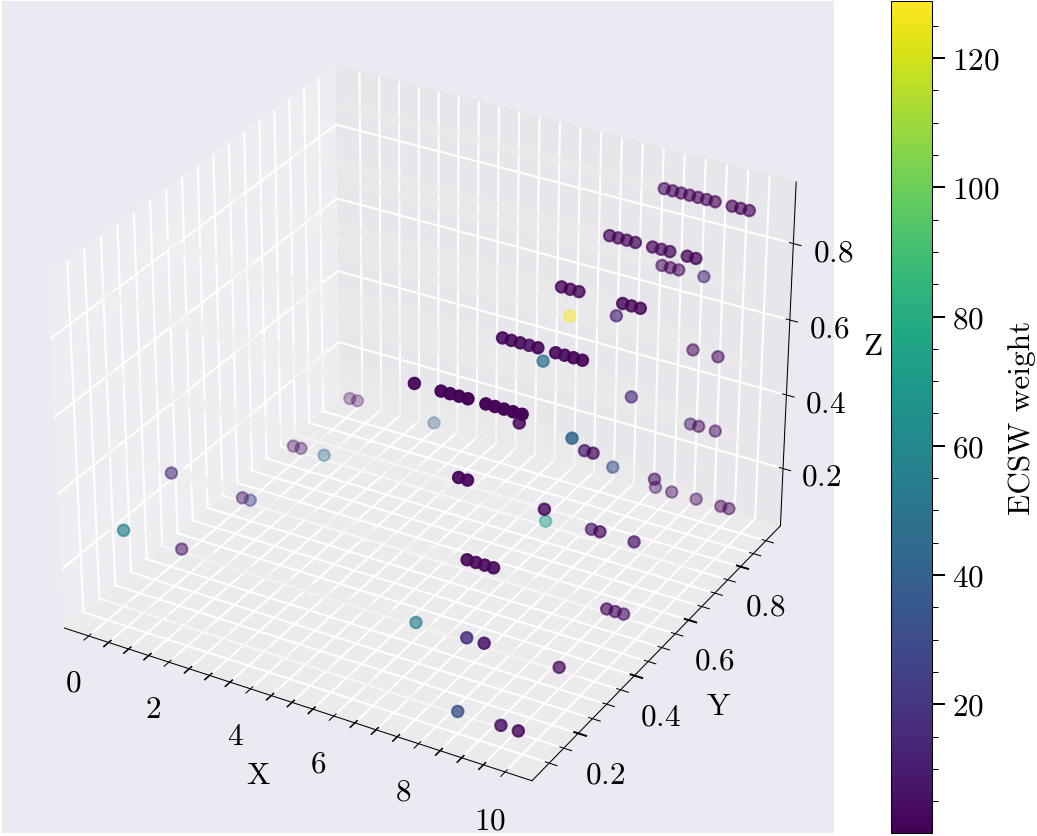

In [18]:
fig, ax = plot_ecsw_weights_3d(prob.mesh, x_nnls_m, projection='3d')

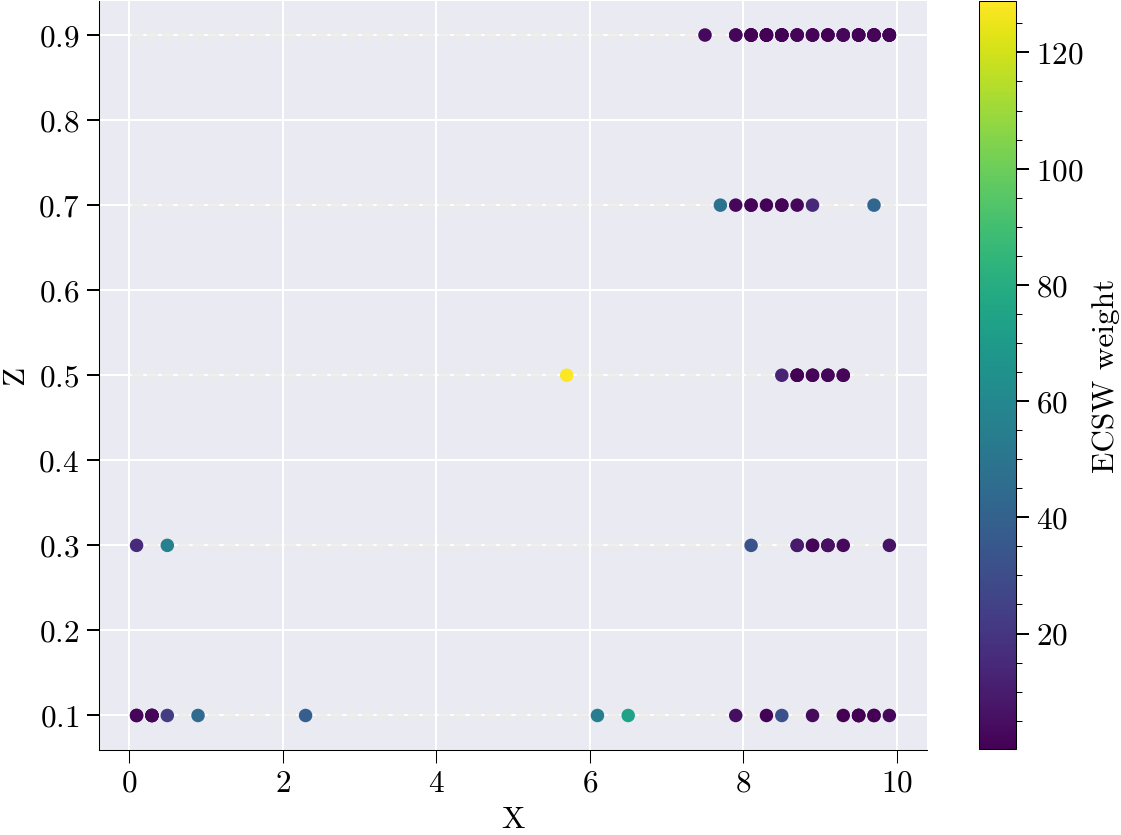

In [19]:
fig, ax = plot_ecsw_weights_3d(prob.mesh, x_nnls_m, projection='projected', plane='xz')

### Run HyperROM simulation


In [20]:
# Run the hyper-reduced ROM simulation using the NNLS weights
#   x_nnls_m : array of non-negative least squares coefficients,
#              used here to weight the reduced basis contributions
#rom will contain the hyper_rom solution as an attribute
# rom.run_hyper_rom_simulation(np.random.rand(640));
rom.run_hyper_rom_simulation_ecsw(x_nnls_m)

Snap 1/64 params=[0.89781157 1.6046292 ]
1 0.043842856835650354
2 3.7646221768423956e-05
Snap 2/64 params=[0.63622413 1.23471286]
1 0.0027701497923506065
2 1.036979402077552e-06
Snap 3/64 params=[0.52065523 1.99901204]
1 0.022289257798724652
2 8.596876685910646e-05
Snap 4/64 params=[0.75880087 1.34914577]
1 0.025043070788702118
2 7.588439215912215e-05
Snap 5/64 params=[0.84142984 1.85704593]
1 0.007250502287875041
2 7.497437795390831e-06
Snap 6/64 params=[0.56418783 1.4911119 ]
1 0.005970113715649721
2 5.330025157127281e-06
Snap 7/64 params=[0.71863756 1.74244539]
1 0.0028415883058581907
2 1.14408319902074e-06
Snap 8/64 params=[0.94118969 1.09689665]
1 0.02446539757200717
2 6.396031720614456e-05
Snap 9/64 params=[0.97892711 1.922586  ]
1 0.01760944565406187
2 4.289224211113785e-05
Snap 10/64 params=[0.74053339 1.2927288 ]
1 0.003960655943631752
2 2.014241455765068e-06
Snap 11/64 params=[0.60164858 1.53651637]
1 0.012710487730671318
2 2.4468748243702075e-05
Snap 12/64 params=[0.86347646

([0.444177045149579,
  0.4258429777689149,
  0.2953737298988106,
  0.44534873586704304,
  0.39814431499447495,
  0.3615443177907265,
  0.37870047741429175,
  0.5443914384022343,
  0.4232243400961496,
  0.4494952277532845,
  0.36828968793096245,
  0.5052409934730927,
  0.4041096315091716,
  0.43428959153994384,
  0.3567797443887792,
  0.4802267830372211,
  0.429182319963854,
  0.4125765247096635,
  0.3347831370104017,
  0.5256720042201077,
  0.4445558591317357,
  0.4353195399178526,
  0.36323807517199996,
  0.5258359658529105,
  0.44490090093056467,
  0.4803637206689354,
  0.32966822488797215,
  0.44538746017749725,
  0.370079063503127,
  0.36305317219881017,
  0.38064366824075524,
  0.5050001321249264],
 [5.218938480280777,
  6.815436688591331,
  6.290677343761241,
  6.778154874746879,
  6.907409192637819,
  6.736376045021769,
  6.813376972973323,
  7.001017741361504,
  6.9090432900621614,
  7.072292726894828,
  6.836808378521691,
  7.017301436614219,
  6.582124398029652,
  6.767333217

In [21]:
# Convert the list of nonlinear hyper-ROM solutions into a NumPy array
NLS_hyper_rom = np.asarray(rom.hyper_rom_solutions)

# Retrieve the raw speed-up factors computed by the ROM
hyper_ROM_speed_up = rom.hyper_speed_up

# Drop the first element (often the full-order baseline) to analyze only relative speed-ups
hyper_ROM_speed_up = hyper_ROM_speed_up[1:]

# Fetch the relative error of the hyper-reduced ROM from the ROM object
hyper_ROM_relative_error = rom.hyper_rom_error

### Hyper ROM vs Full order solution performance statistics


ROM Accuracy Report

Global Errors:
L2 Error:                 7.4304e-03
Relative L2 Error:        4.2637e-03
L∞ Error:                 1.6926e-03
Relative L∞ Error:        3.1761e-03
RMSE:                     5.6636e-04
MAE:                      4.0655e-04

Statistical Fit:
R² Score:                 1.0000
Explained Variance:       1.0021

Error Distribution:
Median Error:             -1.5617e-04
95th Percentile Error:    1.1779e-03

Time/Parameter-Dependent Errors:
Average Rel L2 Error over time/parameter: 1.3189e-04
Max Rel L2 Error over time/parameter: 1.7012e-04
Min Rel L2 Error over time/parameter: 9.2304e-05
―――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――――

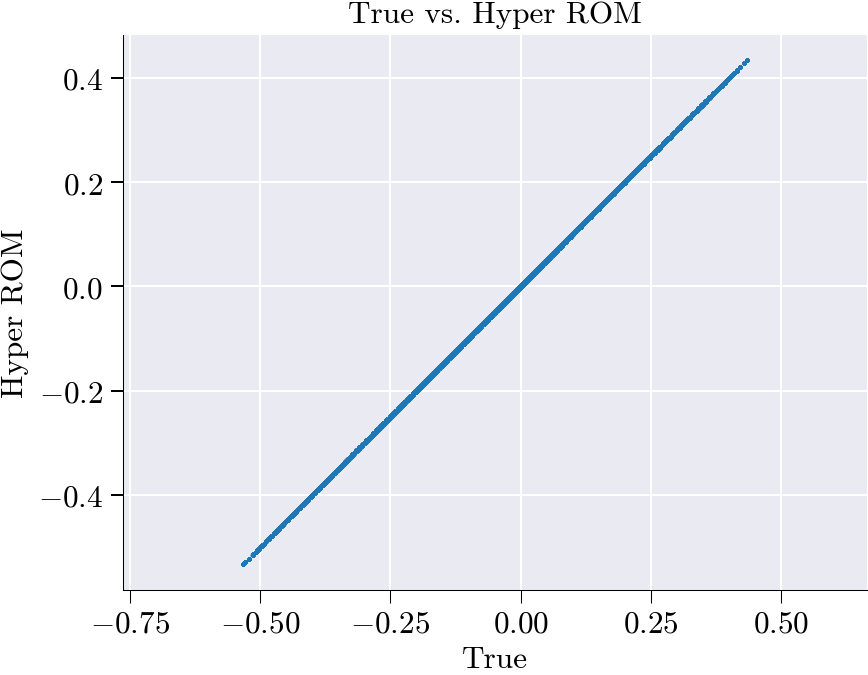

spatial_shape not given → skipping spatial snapshots.
--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


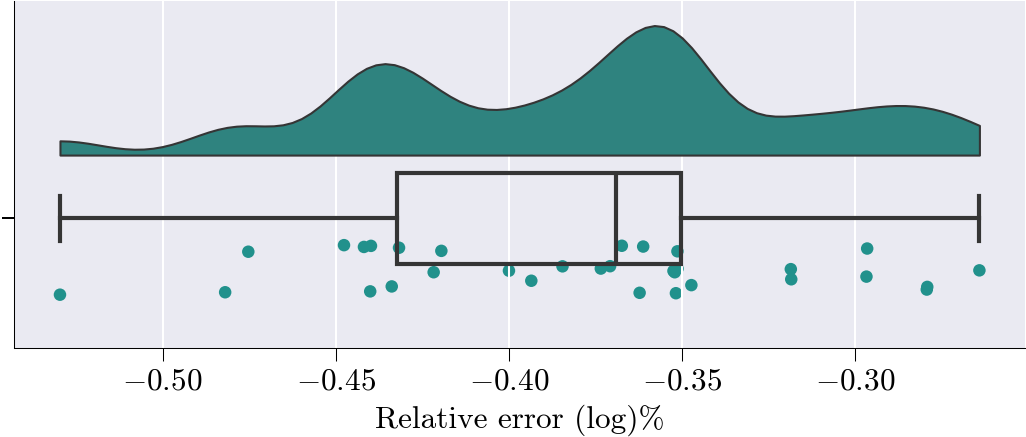

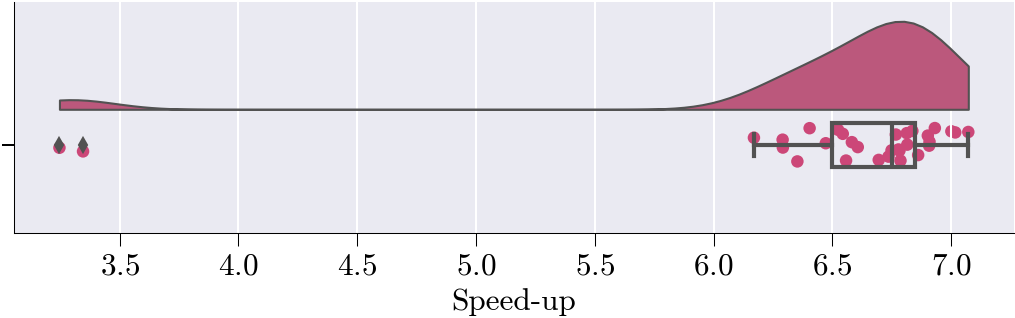

In [22]:
# --- Hyper-reduced ROM error analysis ---

# Compute a flat matrix of error metrics comparing true nonlinear solutions to hyper-ROM approximations
matrix = compute_rom_error_metrics_flat(NLS_test, NLS_hyper_rom)

# Produce a text-based report summarizing these hyper-ROM error metrics
generate_rom_error_report(matrix)

# Plot diagnostic figures: error vs. speed-up for the hyper-reduced ROM
plot_rom_error_diagnostics_flat(
    NLS_test,                   # full-order (true) solution snapshots
    NLS_hyper_rom,              # hyper-ROM-generated solution snapshots
    hyper_ROM_relative_error,   # precomputed relative error of the hyper-ROM
    hyper_ROM_speed_up,         # precomputed speed-up factor of the hyper-ROM
    sim_axis=['True', 'Hyper ROM'], 
    metrics=matrix              # the matrix of error metrics just computed
)

